## 📌 Project Objective
This project aims to enhance real estate investment decisions using predictive modeling. By analyzing various housing features, I have built and compare machine learning models to predict house prices accurately.

##  Dataset Overview – Ames Housing Dataset
The **Ames Housing Dataset** contains detailed records of residential homes sold in **Ames, Iowa**, from 2006 to 2010. It is a modern, rich alternative to the classic Boston Housing dataset.

- 🏠 **Total Records (Rows):** 2,930 houses  
- 📊 **Total Features (Columns):** 80 attributes  
- 🎯 **Target Variable:** `SalePrice` (the property's sale price in USD)

---

###  Feature Categories

| Category         | Example Columns                         | Description                                         |
|------------------|-----------------------------------------|-----------------------------------------------------|
| **Structural**   | `Gr_Liv_Area`, `Total_Bsmt_SF`          | Size and layout of the house                        |
| **Quality**      | `Overall_Qual`, `Exter_Qual`            | Quality ratings of overall and exterior features    |
| **Location**     | `Neighborhood`, `Lot_Config`            | Location and lot configuration                      |
| **Amenities**    | `Garage_Cars`, `Fireplaces`, `Pool_Area`| Presence and size of garage, fireplace, pool, etc.  |
| **Time-Based**   | `Year_Built`, `Yr_Sold`, `Garage_Yr_Blt`| Years related to construction and sale              |

---



---


## 📥 Step 1: Load and Preview the Dataset

Let's  begin by importing the Ames Housing dataset using `pandas`. This allows us to explore the structure of the data — including the number of rows and columns — and preview the first few records to understand what kind of features are available.


In [ ]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('/content/AmesHousing.csv')

# View basic structure
print(df.shape)
df.head()

(2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 🔍 Step 2: Check for Missing Values

Before proceeding with data cleaning,  check how many missing (null) values are present in each column. This helps us decide which columns to drop or impute. Below are the top 20 columns with the most missing values.


In [ ]:
# See how many nulls are in each column
df.isnull().sum().sort_values(ascending=False).head(20)


,0
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
Fireplace Qu,1422
Lot Frontage,490
Garage Qual,159
Garage Yr Blt,159
Garage Cond,159


##  Step 3: Handle Missing Values

Some columns have too many missing values and are not essential to the price prediction task. So drop those if they exist in the dataset.

For the remaining columns:
-  Fill **numerical columns** with the **median** value to preserve central tendency.
- Fill **categorical columns** with `'None'` to indicate the absence of a feature.

This ensures that the dataset is clean and ready for further processing.


In [ ]:
# List of columns to drop if they exist
cols_to_drop = ['PoolQC', 'Alley', 'Fence', 'MiscFeature', 'FireplaceQu']

# Only drop columns that are present in your dataset
cols_present = [col for col in cols_to_drop if col in df.columns]

df.drop(cols_present, axis=1, inplace=True)

# Fill numerical nulls with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Fill categorical nulls with 'None'
df.fillna("None", inplace=True)
print(df.shape)  # Should return (rows, columns) like (1450, 80)



(2930, 80)


##  Step 4: Standardize Column Names

To avoid issues when referencing column names in code (especially those with spaces),  replace all spaces in column names with underscores (`_`). This makes feature names cleaner and code easier to write.


In [ ]:
df.columns = df.columns.str.replace(' ', '_')


##  Step 5: Feature Engineering

 Create new features to capture more relevant information from existing columns:

-  `House_Age`: How old the house is at the time of sale (`Yr_Sold - Year_Built`)
-  `Total_SF`: Total square footage including basement, garage, and living area
- `Has_Basement`: Binary flag indicating if the house has a basement
-  `Remodeled`: 1 if the house was remodeled, 0 if not (`Year_Built` ≠ `Year_Remod/Add`)
-  `Porch_SF_Total`: Combined area of all porch types (open, enclosed, seasonal, screened)

These new features are designed to improve model performance and make the input data more expressive.


In [ ]:
#  FEATURE ENGINEERING (Add after cleaning & renaming columns)
df['House_Age'] = df['Yr_Sold'] - df['Year_Built']
df['Total_SF'] = df['Gr_Liv_Area'] + df['Total_Bsmt_SF'] + df['Garage_Area']
df['Has_Basement'] = df['Total_Bsmt_SF'].apply(lambda x: 1 if x > 0 else 0)
df['Remodeled'] = (df['Year_Built'] != df['Year_Remod/Add']).astype(int)
df['Porch_SF_Total'] = df['Open_Porch_SF'] + df['Enclosed_Porch'] + df['3Ssn_Porch'] + df['Screen_Porch']


##  Step 6: Explore Target Variable – Sale Price

 Begin our EDA by examining the distribution of the target variable: `SalePrice`. This helps us understand:

- Whether the distribution is **normal or skewed**
- The **range** and **spread** of prices
- Presence of **outliers** or extreme values

This is useful for deciding whether to apply transformations (e.g., log) and for model choice.


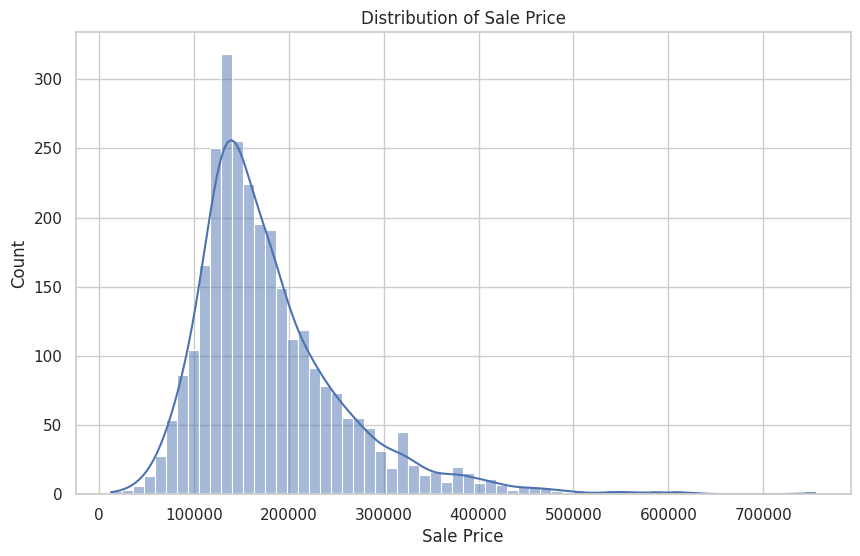

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of Sale Price
sns.histplot(df['SalePrice'], kde=True)
plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.show()


##  Step 7: Apply Log Transformation to Sale Price

The original `SalePrice` distribution is right-skewed. To make it more normally distributed (which many regression models prefer), apply a **logarithmic transformation**.

This helps:
- Reduce the effect of outliers
- Improve model performance
- Make relationships with other features more linear

 then visualize the new `Log_SalePrice` column.


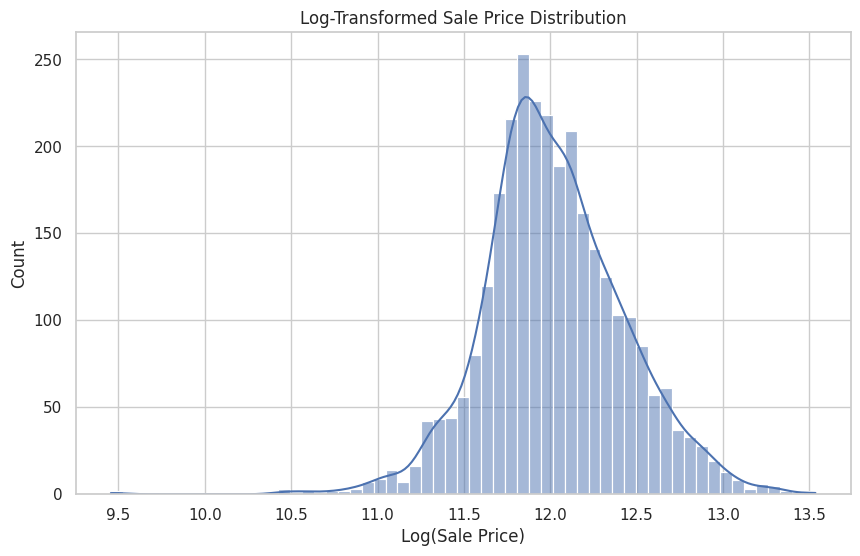

In [ ]:
import numpy as np

# Create a new column for log-transformed SalePrice
df['Log_SalePrice'] = np.log(df['SalePrice'])

# Plot the distribution
sns.histplot(df['Log_SalePrice'], kde=True)
plt.title("Log-Transformed Sale Price Distribution")
plt.xlabel("Log(Sale Price)")
plt.ylabel("Count")
plt.show()


## 📈 Step 8: Correlation Analysis – Top Predictors of Sale Price

To understand which features are most influential in predicting `SalePrice`,  calculate the **correlation matrix** for numeric columns and extract the **top 10 positively correlated features**.

This helps:
- Identify strong linear relationships
- Guide feature selection for modeling
- Spot multicollinearity (if features are too correlated with each other)

 visualize the results using a horizontal bar chart for clarity.


Top 10 Correlated Features with SalePrice:
LogSalePrice     0.946303
Log_SalePrice    0.946303
Overall Qual     0.799262
Gr Liv Area      0.706780
Garage Cars      0.647812
Garage Area      0.640381
Total Bsmt SF    0.632164
1st Flr SF       0.621676
Year Built       0.558426
Full Bath        0.545604
Name: SalePrice, dtype: float64


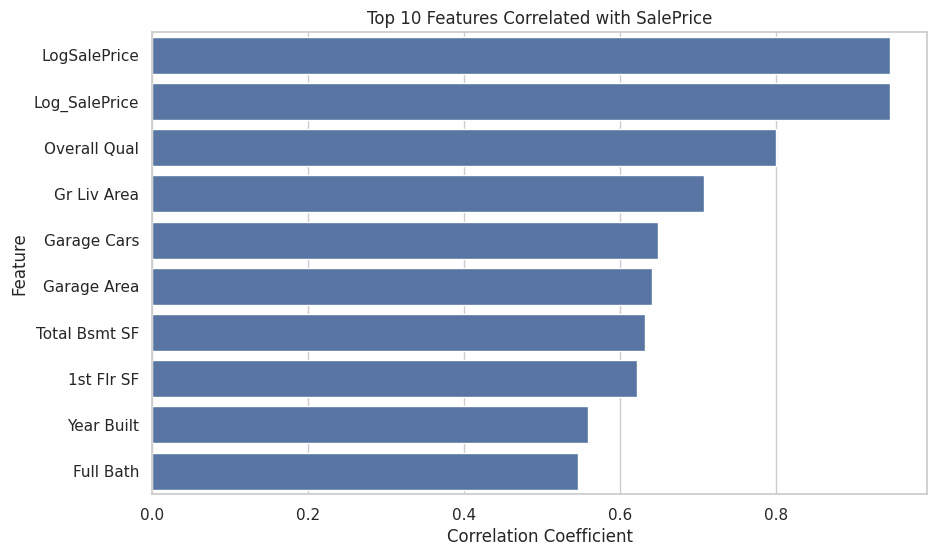

In [ ]:
# Compute correlation matrix for numeric columns
corr_matrix = df.corr(numeric_only=True)

# Get top 10 most positively correlated features with SalePrice
top_corr = corr_matrix['SalePrice'].sort_values(ascending=False)[1:11]
print("Top 10 Correlated Features with SalePrice:")
print(top_corr)

# Plot as bar chart
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top 10 Features Correlated with SalePrice")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.show()


## 📉 Step 9: Relationship – Living Area vs Sale Price

 Visualize how the **Above Ground Living Area (`Gr_Liv_Area`)** affects the **Sale Price** using a scatter plot.

This helps:
- Detect a **linear relationship** between the two variables
- Identify potential **outliers** (e.g., large houses with low prices)
- Confirm that `Gr_Liv_Area` is a strong predictor for modeling


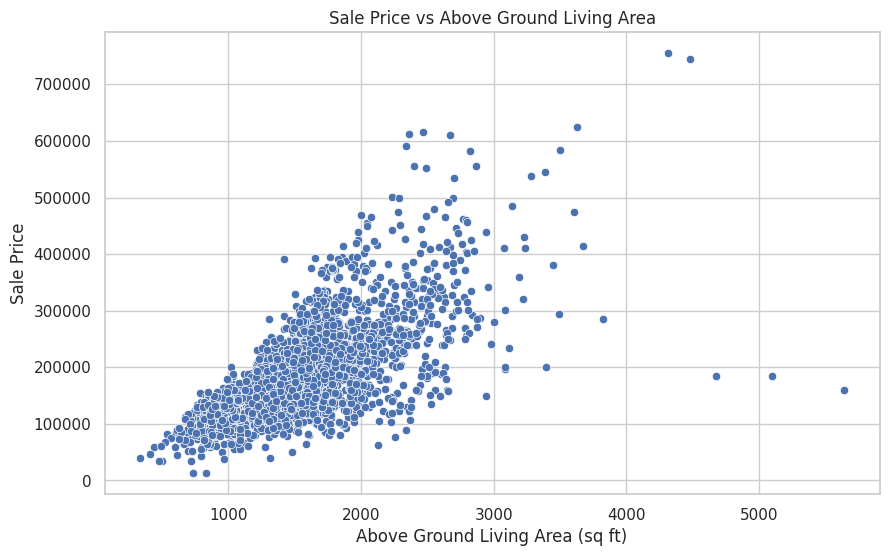

In [ ]:
sns.scatterplot(x='Gr_Liv_Area', y='SalePrice', data=df)
plt.title("Sale Price vs Above Ground Living Area")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price")
plt.show()


##  Step 10: Boxplot – Overall Quality vs Sale Price

This boxplot shows how the **Overall Quality rating (`Overall_Qual`)** affects `SalePrice`.

Key insights:
- Houses with higher quality ratings tend to have **higher median prices**
- The plot reveals the **spread** of sale prices within each quality level
- Helps confirm that `Overall_Qual` is a **high-impact predictor**

This kind of plot is helpful for understanding **categorical ordinal variables**.


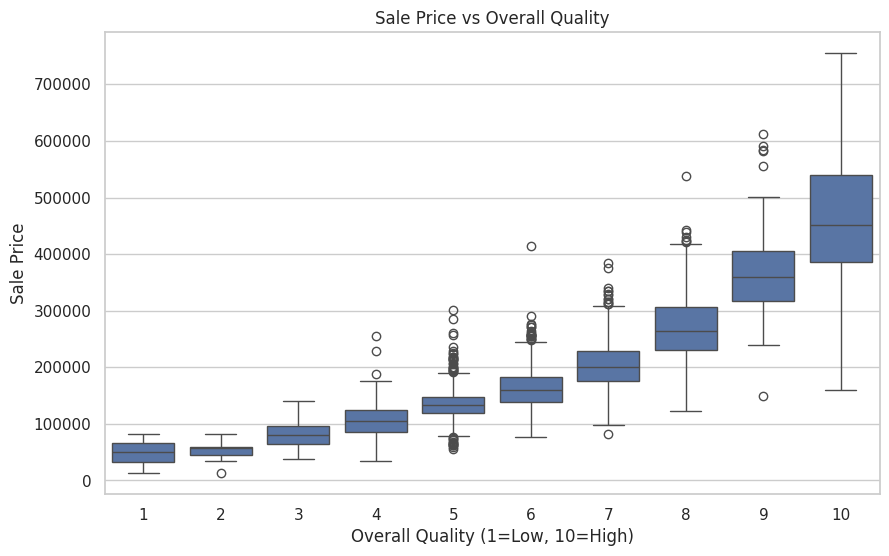

In [ ]:
sns.boxplot(x='Overall_Qual', y='SalePrice', data=df)
plt.title("Sale Price vs Overall Quality")
plt.xlabel("Overall Quality (1=Low, 10=High)")
plt.ylabel("Sale Price")
plt.show()


##  Step 11: Boxplot – Sale Price by Neighborhood

Location is one of the most important factors in real estate pricing. This boxplot shows how `SalePrice` varies across different `Neighborhood`s.

Insights:
- Helps identify **high-value** and **low-value** neighborhoods
- Reveals the **spread** and **outliers** in each neighborhood
- Useful for **location-based feature engineering** or encoding strategies

 use a wider figure and rotated labels for better readability.


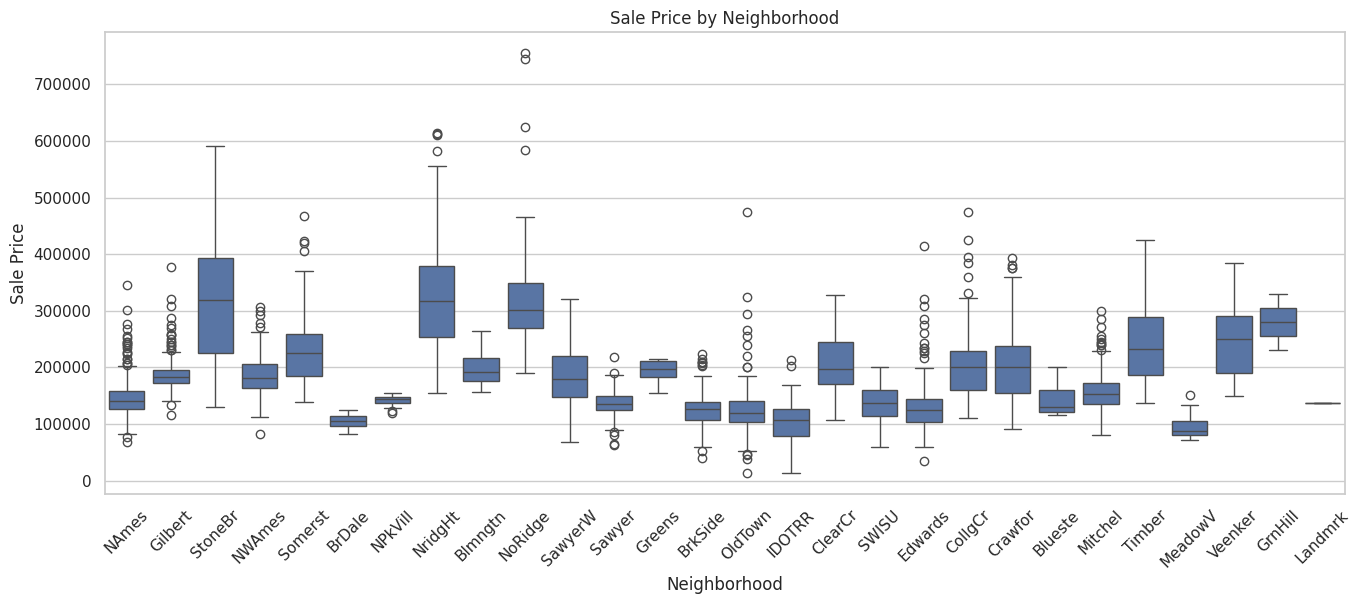

In [ ]:
plt.figure(figsize=(16, 6))  # Wide plot for readability
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.title("Sale Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Sale Price")
plt.xticks(rotation=45)
plt.show()


##  Step 12: Trend Analysis – Year Built vs Sale Price

This line plot explores how **`SalePrice` trends over different construction years (`Year_Built`)**.

Key takeaways:
- Shows how **newer houses** are generally priced higher
- Helps detect **historical pricing trends** in the dataset
- Useful for time-based feature insights like house age or market cycles

 first sort the data by `Year_Built` to smooth the line and reveal a clearer pattern.


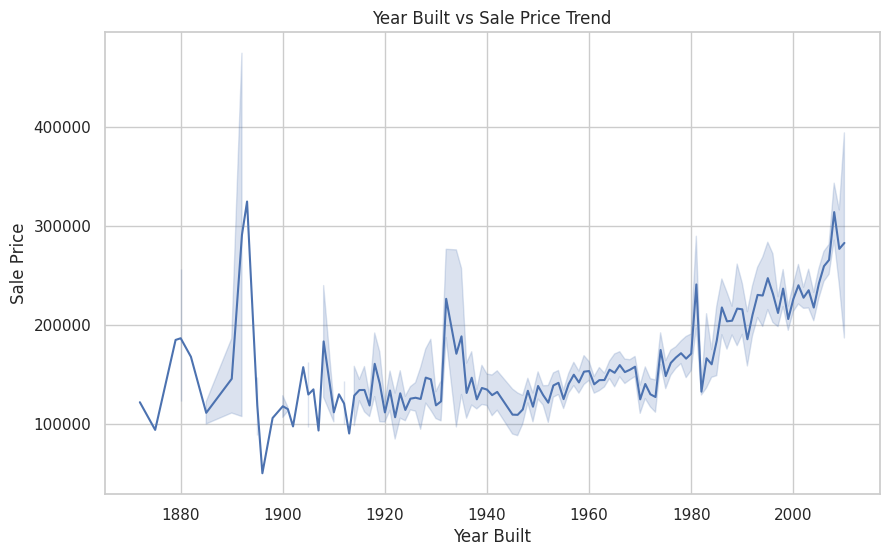

In [67]:
# Sort data by YearBuilt for a smoother line
df_sorted = df.sort_values('Year_Built')

sns.lineplot(x='Year_Built', y='SalePrice', data=df_sorted)
plt.title("Year Built vs Sale Price Trend")
plt.xlabel("Year Built")
plt.ylabel("Sale Price")
plt.show()


##  Step 13: Heatmap – Top 15 Correlated Features

To understand how key features interact with each other and with `SalePrice`,  create a heatmap of the top 15 most correlated features.

This helps us:
- Visualize **feature-to-feature correlations**
- Spot **redundant features** (very high inter-correlation)
- Support feature selection and engineering decisions

This is especially useful for understanding which variables are independently useful vs. overlapping.


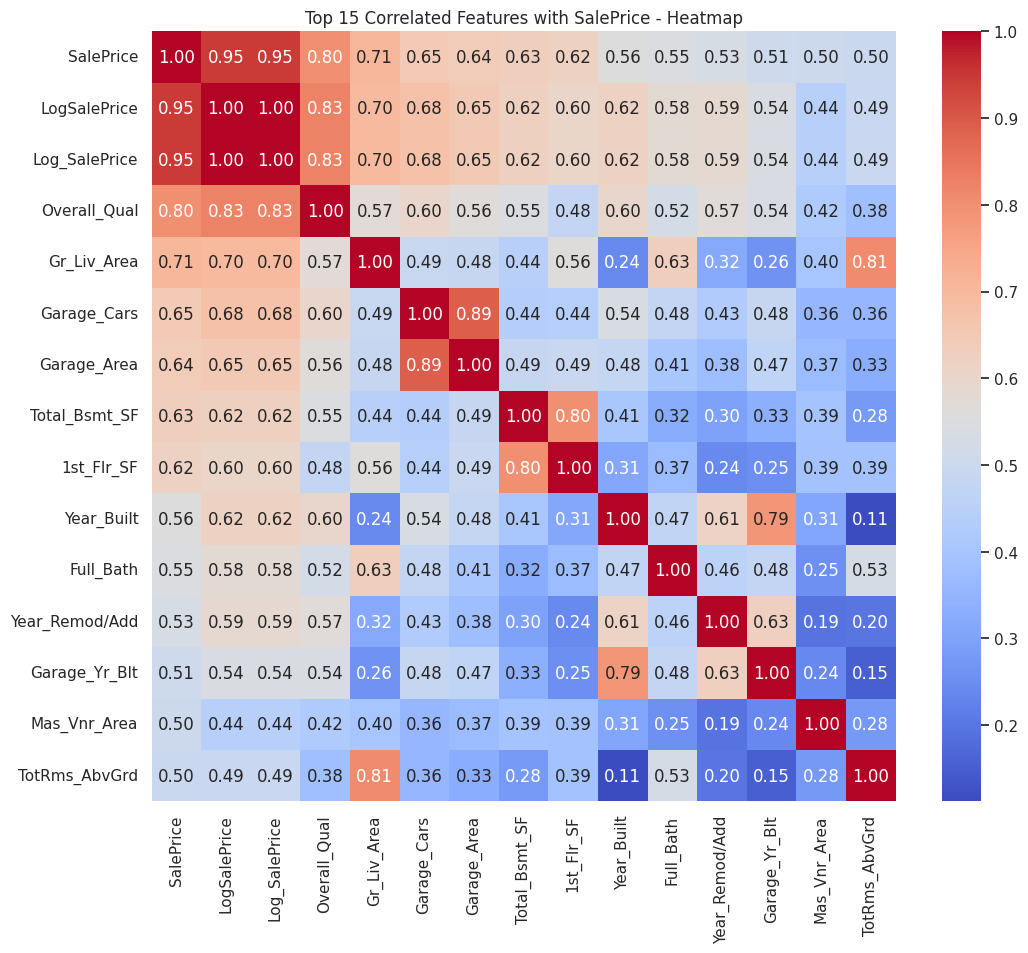

In [ ]:
import numpy as np

# Compute the correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap for top 15 correlated features with SalePrice
top_corr_features = corr['SalePrice'].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Top 15 Correlated Features with SalePrice - Heatmap")
plt.show()


##  Step 14: Feature Selection

 Now define the input features (`X`) and target variable (`y`) for this machine learning model.

Selected features include:
- Original strong predictors like `Gr_Liv_Area`, `Overall_Qual`, `Garage_Cars`
- Engineered features like `House_Age`, `Total_SF`, `Has_Basement`, and `Remodeled`

These features were chosen based on domain knowledge, EDA insights, and correlation analysis. The target variable remains `SalePrice`.


In [ ]:
selected_features = ['Gr_Liv_Area', 'Overall_Qual', 'Garage_Cars',
                     'Total_Bsmt_SF', '1st_Flr_SF', 'Year_Built',  # original
                     'House_Age', 'Total_SF', 'Has_Basement', 'Remodeled', 'Porch_SF_Total']  # new

X = df[selected_features]
y = df['SalePrice']


##  Step 15: Train-Test Split & Random Forest Model

Now that finalized the selected features, let's proceed to:

1. **Add engineered features** to the dataset
2. Define the full set of predictors (`X`) and the target (`y`)
3. Split the data into **training** and **testing** sets (80/20)
4. Train a **Random Forest Regressor**, a powerful ensemble model that handles non-linear relationships well
5. Generate predictions on the test set

This sets the stage for evaluating and comparing model performance.


In [ ]:
# Add engineered features to df (do this first)
df['House_Age'] = df['Yr_Sold'] - df['Year_Built']
df['Total_SF'] = df['Gr_Liv_Area'] + df['Total_Bsmt_SF'] + df['Garage_Area']
df['Has_Basement'] = df['Total_Bsmt_SF'].apply(lambda x: 1 if x > 0 else 0)
df['Remodeled'] = (df['Year_Built'] != df['Year_Remod/Add']).astype(int)
df['Porch_SF_Total'] = df['Open_Porch_SF'] + df['Enclosed_Porch'] + df['3Ssn_Porch'] + df['Screen_Porch']

# Define all features (including engineered)
selected_features = ['Gr_Liv_Area', 'Overall_Qual', 'Garage_Cars',
                     'Total_Bsmt_SF', '1st_Flr_SF', 'Year_Built',
                     'House_Age', 'Total_SF', 'Has_Basement',
                     'Remodeled', 'Porch_SF_Total']

X = df[selected_features]
y = df['SalePrice']

# Split after adding features
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model after split
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set with the same features
y_rf_pred = rf_model.predict(X_test)

## 📊 Step 16: Model Evaluation – Random Forest Performance

 Evaluate the performance of the trained Random Forest Regressor using three key regression metrics:

- **MAE (Mean Absolute Error):** Average of absolute prediction errors (lower is better)
- **RMSE (Root Mean Squared Error):** Penalizes large errors more (sensitive to outliers)
- **R² Score:** Proportion of variance in the target explained by the model (closer to 1 is better)

This provides a quantitative view of how well the model performs on unseen data.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, y_rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_rf_pred))
rf_r2 = r2_score(y_test, y_rf_pred)

print(f"📊 Random Forest Results:")
print(f"MAE: ₹{rf_mae:,.2f}")
print(f"RMSE: ₹{rf_rmse:,.2f}")
print(f"R² Score: {rf_r2:.4f}")


📊 Random Forest Results:
MAE: ₹18,960.66
RMSE: ₹32,291.63
R² Score: 0.8699


## 🎯 Step 17: Actual vs Predicted Sale Prices

This scatter plot compares the **actual sale prices** (`y_test`) with the **predicted prices** from the Random Forest model.

Highlights:
- The closer the points are to the **diagonal red line**, the more accurate the predictions.
- Outliers or patterns far from the line may indicate **model bias** or **missing variables**.
- A good spread around the diagonal suggests **reasonable generalization**.

This is one of the most important diagnostic visuals in regression tasks.


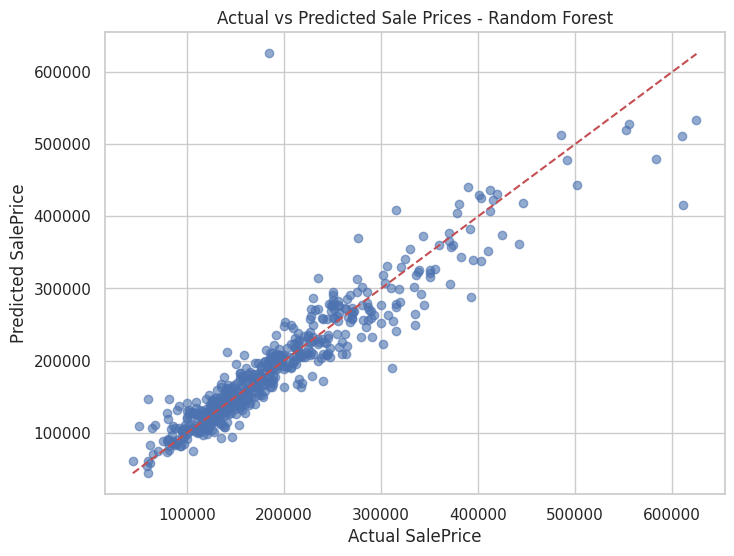

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_rf_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonal line
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted Sale Prices - Random Forest")
plt.show()


## 📉 Step 18: Residuals Distribution Plot

Residuals = Actual - Predicted values

This plot shows how well the model's predictions align with reality:

- **Centered around zero** → Good predictions overall
- **Spread** → Tells us about the model’s error variance
- **Shape** → A roughly normal (bell-shaped) curve means errors are random (ideal)
- **Skew or heavy tails** → Might indicate outliers or features not captured by the model

This is an essential step to validate model assumptions.


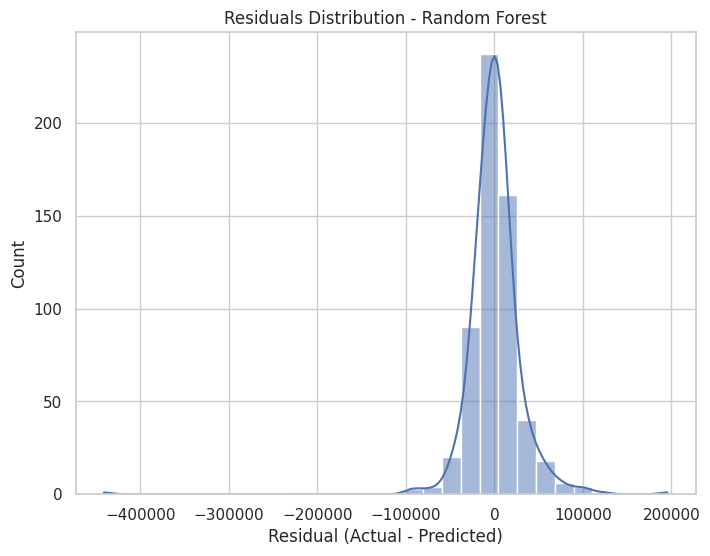

In [ ]:
residuals = y_test - y_rf_pred

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residuals Distribution - Random Forest")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()


##  Step 19: Boxplot of Residuals – Error Spread

This boxplot visualizes the **distribution of residuals (prediction errors)** from the Random Forest model.

Key insights:
- The **box** represents the interquartile range (middle 50% of errors)
- The **line** inside the box is the median residual
- **Dots** beyond the whiskers show outliers – predictions that were far off

This helps diagnose **model bias, variability**, and the presence of **extreme prediction errors**.


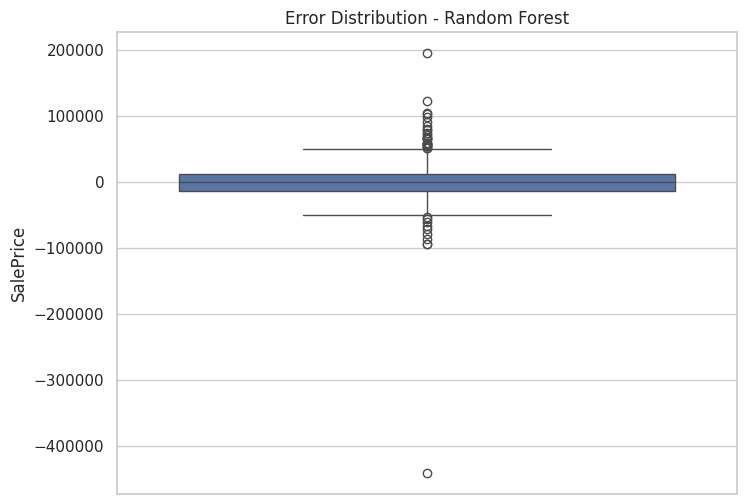

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(residuals)
plt.title("Error Distribution - Random Forest")
plt.show()


## 📌 Step 20: Feature Importance – Random Forest

This bar chart shows the **relative importance of each input feature** used by the Random Forest model.

Key takeaways:
- Features with higher scores contributed **more to predicting SalePrice**
- Helps with **model explainability**, **feature selection**, and business insights

For example, variables like `Overall_Qual`, `Total_SF`, and `Gr_Liv_Area` often have the highest impact in real estate price prediction.


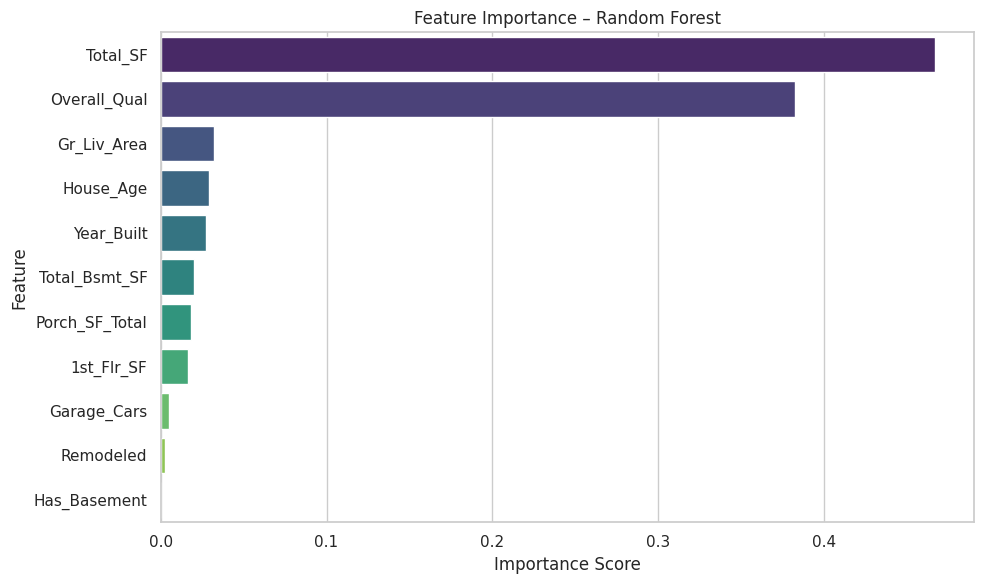

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title("Feature Importance – Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


##  Step 21: XGBoost Regression – Advanced Model

 Now train and evaluate an **XGBoost Regressor**, known for:

- Excellent performance on structured/tabular data
- Built-in regularization to reduce overfitting
- Faster training and prediction compared to many models

 Evaluate its performance using the same MAE, RMSE, and R² metrics.


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize XGBoost Regressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_xgb_pred = xgb_model.predict(X_test)

# Evaluate
xgb_mae = mean_absolute_error(y_test, y_xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_xgb_pred))
xgb_r2 = r2_score(y_test, y_xgb_pred)

print(f"📊 XGBoost Results:")
print(f"MAE: ₹{xgb_mae:,.2f}")
print(f"RMSE: ₹{xgb_rmse:,.2f}")
print(f"R² Score: {xgb_r2:.4f}")


📊 XGBoost Results:
MAE: ₹20,448.81
RMSE: ₹32,040.68
R² Score: 0.8720


## 🎯 Step 22: Actual vs Predicted – XGBoost

This scatter plot shows the relationship between the actual sale prices and the prices predicted by the **XGBoost Regressor**.

Key observations:
- Points **close to the red diagonal line** indicate accurate predictions.
- **Spread and outliers** give insight into variance and model bias.
- A tighter cluster around the line = **better generalization** to test data.

This visual is crucial for diagnosing prediction quality.


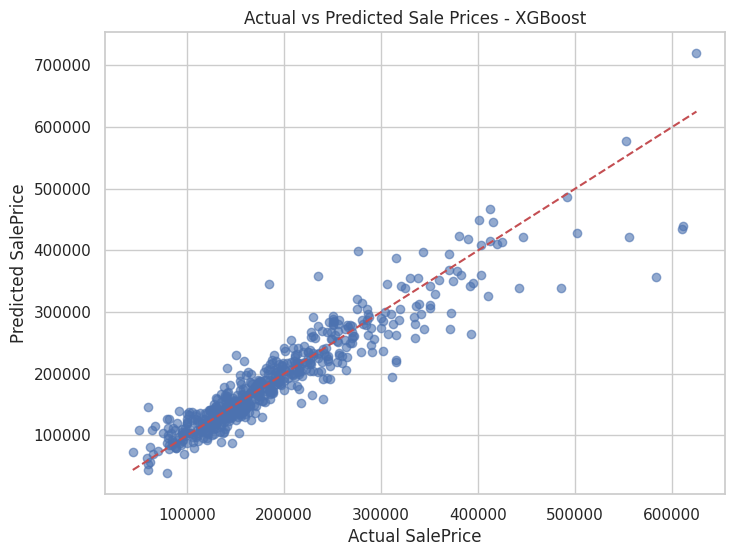

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_xgb_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted Sale Prices - XGBoost")
plt.show()


##  Step 23: Gradient Boosting Regressor (GBR)

 Now apply the **Gradient Boosting Regressor**, an ensemble model that:

- Builds trees sequentially to reduce errors step-by-step
- Often delivers **strong accuracy** with good generalization
- Can handle both bias and variance effectively

This adds another strong model to our comparison list.




In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)


##  Step 24: LightGBM Regressor – High-Speed Gradient Boosting

LightGBM is an advanced boosting algorithm that:

- Uses histogram-based techniques for ultra-fast training
- Supports parallel and GPU learning
- Works well on large datasets with many features

It’s efficient and accurate — a great addition to our model comparison.


In [ ]:
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(random_state=42)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000472 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1515
[LightGBM] [Info] Number of data points in the train set: 2344, number of used features: 11
[LightGBM] [Info] Start training from score 178582.207765


## 📊 Step 25: Evaluation & Feature Importance – LightGBM

 Evaluate the LightGBM model using the same metrics:

- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **R² Score**

 Also visualize:
- **Actual vs Predicted** sale prices to assess prediction spread
- **Feature Importances** to understand what influenced the model most

These help with interpreting the model and comparing it to others.


📊 LightGBM Results:
MAE: ₹19,391.85
RMSE: ₹31,229.53
R² Score: 0.8784


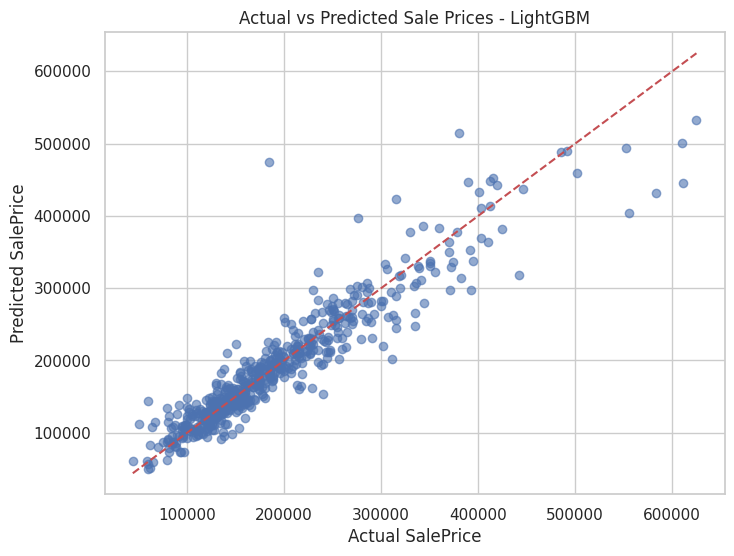

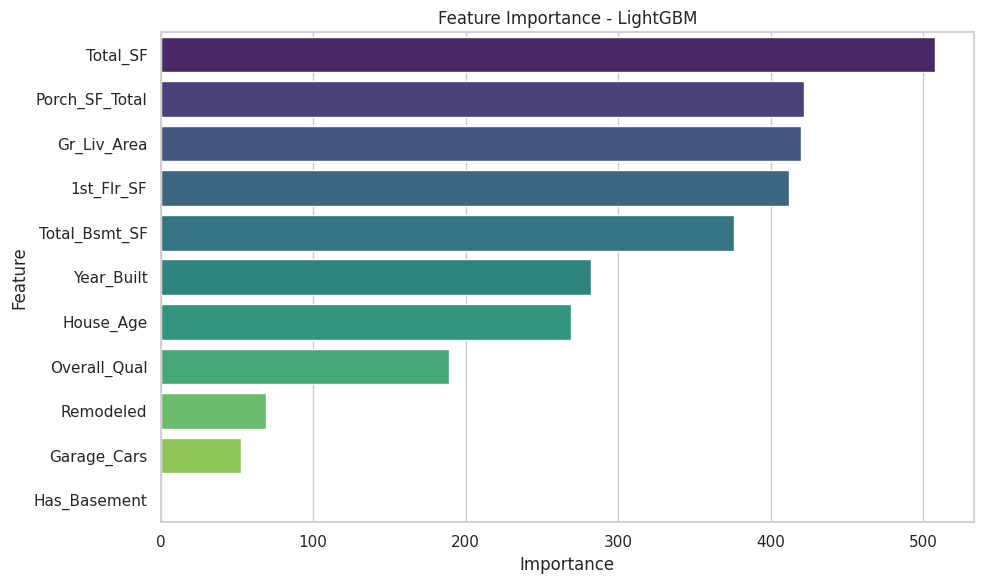

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Evaluation metrics
lgbm_mae = mean_absolute_error(y_test, y_pred_lgbm)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
lgbm_r2 = r2_score(y_test, y_pred_lgbm)

print(f"📊 LightGBM Results:")
print(f"MAE: ₹{lgbm_mae:,.2f}")
print(f"RMSE: ₹{lgbm_rmse:,.2f}")
print(f"R² Score: {lgbm_r2:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lgbm, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted Sale Prices - LightGBM")
plt.show()

# Plot Feature Importance
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title("Feature Importance - LightGBM")
plt.tight_layout()
plt.show()


##  Step 26: Hyperparameter Tuning – Random Forest with RandomizedSearchCV

To improve model performance, we tune key hyperparameters of the Random Forest using **RandomizedSearchCV**:

- `n_estimators`: Number of trees
- `max_depth`: Maximum depth of each tree
- `min_samples_split`, `min_samples_leaf`: Control overfitting
- `max_features`: Number of features to consider at each split

I use **3-fold cross-validation** and search through combinations to find the best set of parameters.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best cross-validation score:", random_search.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
Best cross-validation score: 0.8641734392816974


##  Step 27: Evaluate Tuned Random Forest Model

Using the best hyperparameters found via RandomizedSearchCV, we retrain the Random Forest model and evaluate its performance on the test data.

This step helps confirm that tuning has improved model accuracy and generalization.


In [ ]:
best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print(f"MAE: ₹{mean_absolute_error(y_test, y_pred_best):,.2f}")
print(f"RMSE: ₹{np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_best):.4f}")


MAE: ₹17,856.51
RMSE: ₹30087.27
R² Score: 0.8871


##  Step 27:  Final Tuned Random Forest Model Training & Evaluation

With the optimal hyperparameters found from tuning, Retrain the Random Forest Regressor on the training data.

 Then evaluate its performance on the test set to validate the improvements.


In [ ]:
# Import
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Retrain with best params
best_rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='sqrt',
    max_depth=30,
    random_state=42
)

best_rf.fit(X_train, y_train)

# Predict on test
y_pred_best = best_rf.predict(X_test)

# Evaluate
print(f"MAE: ₹{mean_absolute_error(y_test, y_pred_best):,.2f}")
print(f"RMSE: ₹{np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_best):.4f}")


MAE: ₹17,856.51
RMSE: ₹30087.27
R² Score: 0.8871


##  Step 28: Model Comparison Summary

 Trained and evaluated multiple machine learning models:

- Linear Regression
- Random Forest (Untuned)
- Tuned Random Forest (Best Hyperparameters)
- XGBoost Regressor
- LightGBM Regressor

The performance of each model is compared using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

This gives us a clear view of which model generalizes best on unseen data.


In [ ]:
#  Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1️⃣ Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 2️⃣ Train Random Forest (Untuned)
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 3️⃣ Train Tuned Random Forest (Assuming you already tuned and have best_rf)
y_pred_best = best_rf.predict(X_test)

# 4️⃣ Train XGBoost
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# 5️⃣ Train LightGBM
lgbm = lgb.LGBMRegressor(random_state=42)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

# 6️⃣ Create Comparison Table
results = {
    'Model': ['Linear Regression', 'Random Forest', 'Tuned RF', 'XGBoost', 'LightGBM'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_best),
        mean_absolute_error(y_test, y_pred_xgb),
        mean_absolute_error(y_test, y_pred_lgbm)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_best)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_best),
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_lgbm)
    ]
}

# 7️⃣ Display as DataFrame
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by='R2 Score', ascending=False)

# 8️⃣ Print the final table
print("📊 Model Comparison Results:")
print(comparison_df)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000297 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1515
[LightGBM] [Info] Number of data points in the train set: 2344, number of used features: 11
[LightGBM] [Info] Start training from score 178582.207765
📊 Model Comparison Results:
               Model           MAE          RMSE  R2 Score
2           Tuned RF  17856.513772  30087.265252  0.887092
4           LightGBM  19391.846047  31229.533791  0.878356
3            XGBoost  20448.812500  32040.677146  0.871955
1      Random Forest  18960.664744  32291.625839  0.869942
0  Linear Regression  24938.601816  39364.794191  0.806726


##  Step 29: Save Final Tuned Model

To preserve the best-performing model (Tuned Random Forest), we save it using `joblib`. This allows us to load and use it later for predictions without retraining.


In [ ]:
import joblib
joblib.dump(best_rf, 'final_model_rf.pkl')


['final_model_rf.pkl']

## 📈 Step 30: Actual vs. Predicted – Tuned Random Forest

This scatter plot compares actual sale prices to the model’s predictions.  
- The red dashed line represents perfect predictions (i.e., Actual = Predicted).
- The closer the points are to this line, the better the model's performance.


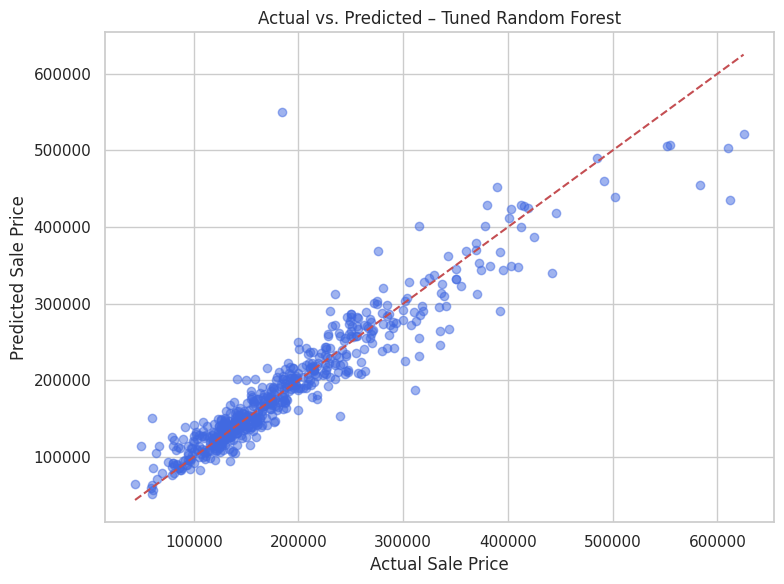

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs. Predicted – Tuned Random Forest")
plt.grid(True)
plt.tight_layout()
plt.show()


##  Step 31: Feature Explainability using SHAP

 Use SHAP values to interpret the model’s behavior and understand which features contribute most to predicting house prices.  
- The summary bar plot below ranks features by their average impact on model output (SHAP value magnitude).


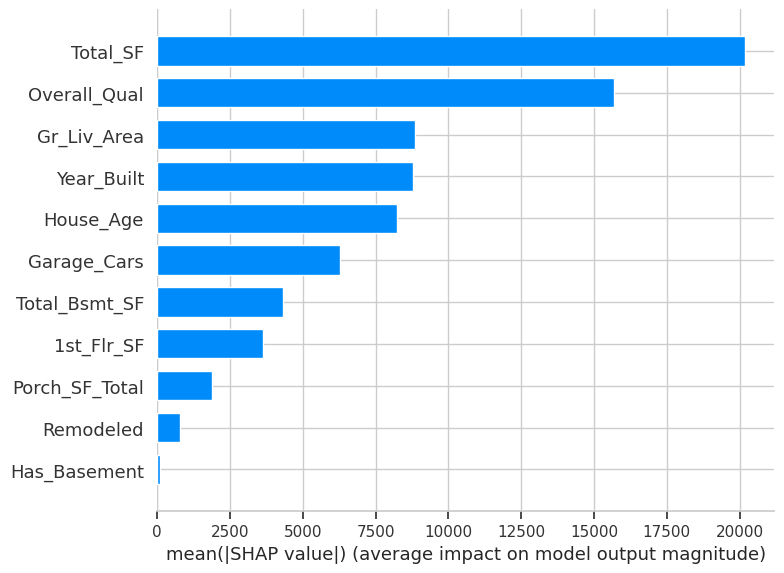

In [ ]:
import shap

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")


##  Step 32:  Investment Scenario Simulation

Let’s simulate how changes in a single feature — **Living Area (Gr_Liv_Area)** — affect the predicted house price, keeping all other variables constant.

This can help real estate investors assess how much value is added with larger living spaces.


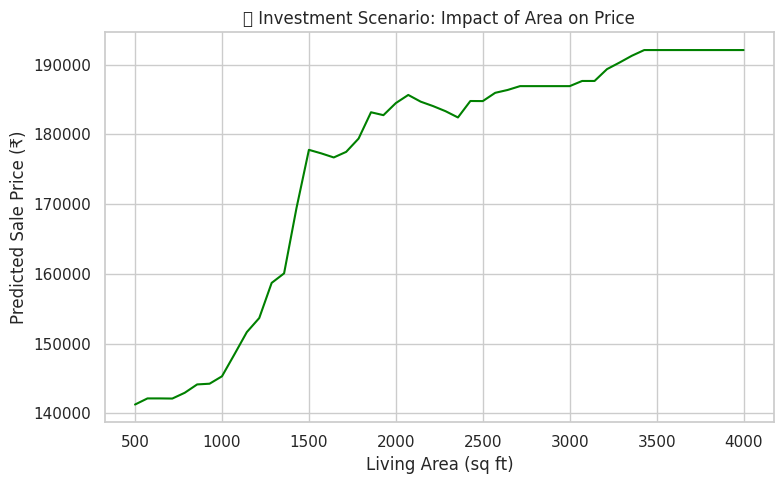

In [ ]:
import numpy as np

# Vary one feature: Gr_Liv_Area (living area)
area_range = np.linspace(500, 4000, 50)
sim_data = X_test.iloc[0].copy()
sim_results = []

for area in area_range:
    sim_data['Gr_Liv_Area'] = area
    sim_results.append(best_rf.predict([sim_data.values])[0])

plt.figure(figsize=(8,5))
plt.plot(area_range, sim_results, color='green')
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Predicted Sale Price (₹)")
plt.title("📈 Investment Scenario: Impact of Area on Price")
plt.grid(True)
plt.tight_layout()
plt.show()


##  Step 33: Neighborhood-Level Price Insights

This bar chart displays the **average house sale price** for each neighborhood. It highlights how **location** plays a major role in real estate pricing, helping investors and analysts prioritize their investment areas.


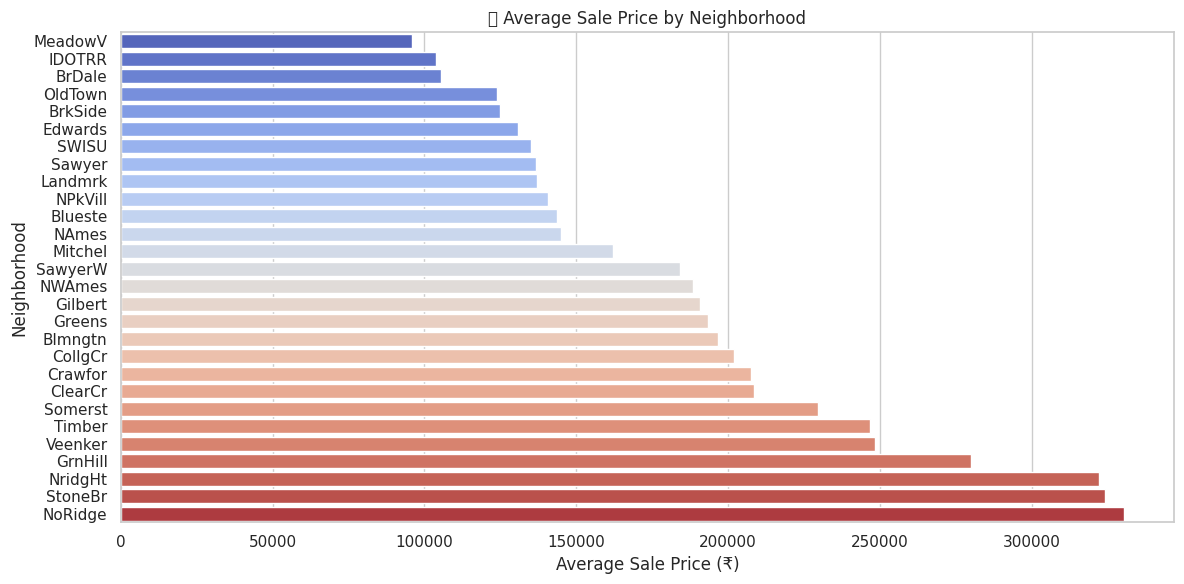

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group sale price by neighborhood
neigh_prices = df.groupby('Neighborhood')['SalePrice'].mean().sort_values()

plt.figure(figsize=(12,6))
sns.barplot(x=neigh_prices.values, y=neigh_prices.index, palette='coolwarm')
plt.title(" Average Sale Price by Neighborhood")
plt.xlabel("Average Sale Price (₹)")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.show()


##  Step 34: ML Pipeline Flowchart

To summarize the complete end-to-end ML workflow, here's a simple flowchart showing each key stage of this house price prediction project.


In [ ]:
from graphviz import Digraph

dot = Digraph()

dot.node('A', 'Data Collection')
dot.node('B', 'Cleaning + Feature Engineering')
dot.node('C', 'EDA')
dot.node('D', 'Model Building')
dot.node('E', 'Model Comparison')
dot.node('F', 'Tuned RF Selected')
dot.node('G', 'Deployment or Report')

dot.edges(['AB', 'BC', 'CD', 'DE', 'EF', 'FG'])

dot.render('ml_pipeline_flowchart', format='png', cleanup=False)
dot.view()


'ml_pipeline_flowchart.pdf'

##  Investment Simulation: Living Area Impact

To demonstrate model behavior, I created an animated simulation that shows how increasing the above-ground living area (`Gr_Liv_Area`) affects the predicted house price. This dynamic analysis is particularly helpful for investors to understand return potential on size upgrades.


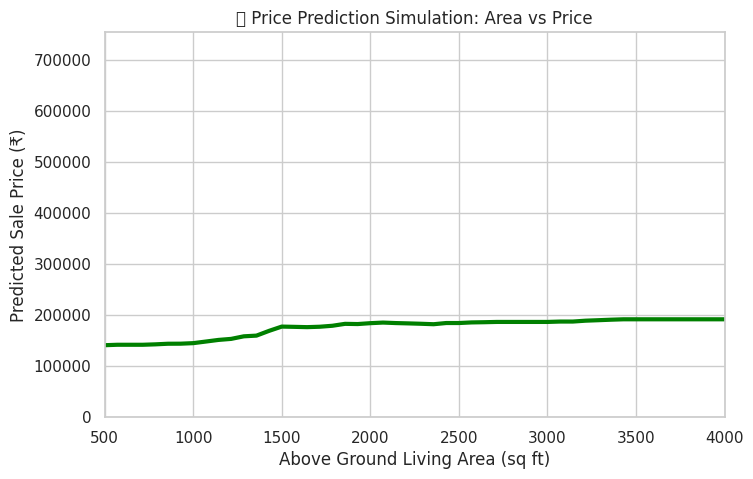

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Make sure matplotlib animations render in Colab
%matplotlib inline

# Create simulation values for Gr_Liv_Area
area_range = np.linspace(500, 4000, 50)

# Copy a sample data point from X_test
sim_data = X_test.iloc[0].copy()
sim_data = sim_data.to_dict()  # Convert to dict for easy update

# Initialize lists to store results
areas = []
predicted_prices = []

# Set up the plot
fig, ax = plt.subplots(figsize=(8,5))
line, = ax.plot([], [], lw=3, color='green')
ax.set_xlim(500, 4000)
ax.set_ylim(0, df['SalePrice'].max())
ax.set_title("📽️ Price Prediction Simulation: Area vs Price")
ax.set_xlabel("Above Ground Living Area (sq ft)")
ax.set_ylabel("Predicted Sale Price (₹)")
ax.grid(True)

# Initialize function
def init():
    line.set_data([], [])
    return line,

# Update function for animation
def update(frame):
    area = area_range[frame]
    sim_data['Gr_Liv_Area'] = area  # Update living area
    input_array = np.array([list(sim_data.values())])
    predicted_price = best_rf.predict(input_array)[0]

    areas.append(area)
    predicted_prices.append(predicted_price)

    line.set_data(areas, predicted_prices)
    return line,

# Create animation
ani = FuncAnimation(fig, update, frames=len(area_range), init_func=init, blit=True)

# Display animation in Colab
HTML(ani.to_jshtml())
